# Monday, February 23rd, 2026

Last week, we worked on documenting our code, learned how to use modules, and how to use the `zip` function.

## Writing your reports

As we have discussed, the reports should be written for a hypothetical reader that is not part of our class. We should make sure to:
 * Define and explain any necessary terms (e.g. primes, Fermat's little theorem, prime-like numbers, false primes, etc.).
 * Include a Markdown cell before each code cell that explains
   * What the code does,
   * How the code works,
   * How it fits into the report (e.g. why are we writing this code?).
 * Present your exploration in a self-motivated narrative way.
   * This includes an Introduction section and a Conclusion section.
     * The introduction should get the reader up to speed on the necessary terms and ideas to describe the main topic of exploration, and let the reader know what we will be exploration.
     * Observations and conclusions should be made throughout the report as we carry out the exploration and generate data.
     * The Conclusion section generally should not include any new information, but should summarize the high-points of the report.
    * The report should not refer to "Exercise 1" or "Part 3" or similar.
      * Do not write the report as though you're just ticking the boxes of what's been asked (however true that may or may not be).
      * Instead, the various tasks discussed in the project page should come up naturally through the narrative that describes our exploration.
 * Make sure to restart the kernel and run all of your cells top-to-bottom before submitting your report to ensure that everything runs as expected.


If you have not already done so, please take some time to read through the [Project Report Guide](https://jllottes.github.io/report_guide.html) on the course webpage. There is also an [Example Report](https://jllottes.github.io/_static/projects/twin_primes.html) that shows the intended style of these reports.

## [Project 1: A prime or not a prime](https://jllottes.github.io/Projects/prime_or_not/prime_or_not.html)

Reminder, [Project 1: A prime or not a prime](https://jllottes.github.io/Projects/prime_or_not/prime_or_not.html) is due this Wednesday at 11:59PM. Your report should be submitted through UBlearns.

We have discussed optimizing the `is_prime` function in-class, and the project page discusses using the `pow` function to speed up the `is_prime_like` function. There is one other subtle optimization that is necessary to find $20$ false primes in a reasonable amount of time.

Let's consider the following experiment. We'll define some functions that just return `True` or `False`. We'll create another set that wait $5$ seconds before returning `True` or `False`. We will use the `sleep` function from the `time` module, which takes in a float `x` and will cause Python to pause for that `x` seconds. To help us keep track of what has been run, these functions will print out some statements indicating what they are doing.

In [1]:
import time

In [2]:
def return_True():
    print('I am returning True.')
    return True

In [3]:
def return_False():
    print('I am returning False.')
    return False

In [4]:
def wait_and_return_True():
    print('I am waiting...',end=' ')
    time.sleep(5)
    print('Now I am returning True.')
    return True

In [5]:
def wait_and_return_False():
    print('I am waiting...', end=' ')
    time.sleep(5)
    print('Now I am returning False.')
    return False

Let's see how Python evaluates Boolean expressions involving these functions. We'll start with an `or` statement involving both the `wait_and_return_False` and `return_True` functions.

In [6]:
t0 = time.time()
if wait_and_return_False() or return_True():
    print('Hello!')
t1 = time.time()
print(t1-t0)

I am waiting... Now I am returning False.
I am returning True.
Hello!
5.005759000778198


In the above experiment, we see that Python first evaluates the `wait_and_return_False` function, and after that has finished moves on to evaluate the `return_True` function. The `return_True` function must be evaluated in order to determine whether the complete `or` statement will be `True` or `False`. What happens if we evaluate this `or` in the reverse order?

In [7]:
t0 = time.time()
if return_True() or wait_and_return_False():
    print('Hello!')
t1 = time.time()
print(t1-t0)

I am returning True.
Hello!
0.0005247592926025391


We see from the above that Python first evaluates the `return_True` function, but then never bothers to evaluate the `wait_and_return_False` function at all! This is because the complete `or` expression is guaranteed to be `True` as soon as the first part is `True`.

Now let's consider a similar example with an `and` statement.

In [8]:
t0 = time.time()
if wait_and_return_True() and return_False():
    print('Hello!')
t1 = time.time()
print(t1-t0)

I am waiting... Now I am returning True.
I am returning False.
5.00126838684082


In the above experiment, we see that Python first evaluates the `wait_and_return_True` function, and after that has finished moves on to evaluate the `return_False` function. The `return_False` function must be evaluated in order to determine whether the complete `and` statement is `True` or `False`. What happens if we evalute this `and` in the reverse order?

In [9]:
t0 = time.time()
if return_False() and wait_and_return_True():
    print('Done')
t1 = time.time()
print(t1-t0)

I am returning False.
0.003076314926147461


We see from the above that Python first evaluates the `return_False` function, but then never bothers to evaluate the `wait_and_return_True` function at all! This is because the complete `and` expression is guaranteed to be `False` as soon as the first part is `False`.

How does this connect to Project 1? When identifying false primes, we are looking for numbers that are prime-like and are not prime. We can use the `is_prime` and `is_prime_like` functions to form an `and` statement for identifying false primes. From the above discussion, the order in which this `and` statement is formed can make a big difference in execution time.

## List slicing

So far, when working with lists we've discussed how to access specific elements by index using square brackets. That is `my_list[i]` will get the element in the `i`th index of `my_list`.

In [10]:
my_list = ['a','b','c','d','e','f','g','h']

print(my_list[0])
print(my_list[3])
print(my_list[-1])

a
d
h


Sometimes, we might want to get several elements from a list. For example, suppose we want a list containing every other element from `my_list`.

In [11]:
every_other = []

for i in range(len(my_list)):
    if i % 2 == 0:
        every_other.append(my_list[i])

print(every_other)

['a', 'c', 'e', 'g']


In [12]:
every_other = []

for i in range(0,len(my_list),2):
    every_other.append(my_list[i])

print(every_other)

['a', 'c', 'e', 'g']


A more elegant approach is to use **list slicing**. There are several ways that we can take slices of a list.
 - `my_list[start_index:]` will start the slice at `start_index` and go the end of the list.
 - `my_list[:stop_index]` will start the list at the beginning (i.e. `0`) and proceed until one less than `stop_index`.
 - `my_list[start_index:stop_index]`  will start the slice at `start_index` and proceed until one less than `stop_index`.

We can also use negative indices as `stop_index` to count backward from the end of the list. For example, `stop_index=-1` will skip the last element of the list.

In [13]:
print(my_list)
print(my_list[:4])

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
['a', 'b', 'c', 'd']


In [14]:
print(my_list)
print(my_list[3:])

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
['d', 'e', 'f', 'g', 'h']


In [15]:
print(my_list)
print(my_list[3:7])

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
['d', 'e', 'f', 'g']


If we compare the use of list slicing with the use of the `range` function, we can see that they share a lot in common. 
Instead of using commas to separate the start and stop indices, we use colons.
Just like the `range` function, we can optionally include a step size to our slice. For example:
- `my_list[::skip]` will start at the beginning of the list and go to the end, but will go in steps of `skip`.
- `my_list[start_index:stop_index:skip]` will start at `start_index`, proceed in steps of `skip`, and will stop when the index is greater than or equal to `stop_index`.

In [ ]:
my_list[::2]

**Exercise:** Generate a list `cubes` that stores the cubes of the first $40$ positive integers. Then print out the third through tenth of these cubes (i.e. index-`2` through index-`9`).

In [18]:
cubes = []
for i in range(1,41):
    cubes.append(i**3)

In [21]:
print(cubes[2:10])

[27, 64, 125, 216, 343, 512, 729, 1000]


**Exercise:** Print out the last ten cubes from the `cubes` list.

In [24]:
print(cubes[-10:])

[29791, 32768, 35937, 39304, 42875, 46656, 50653, 54872, 59319, 64000]


**Exercise:** Print out every third cube from the `cubes` list, starting with the second cube (i.e. the index-`1` entry).

In [32]:
print(cubes[1::3])

[8, 125, 512, 1331, 2744, 4913, 8000, 12167, 17576, 24389, 32768, 42875, 54872]


## List comprehension

So far, we've primarily constructed lists of data by using `for` loops and appending to an empty list. Another option is to use **list comprehension**. The syntax is as follows:

`[<some expression> for <some item> in <some iterable>]`

This will produce a list containing the results of `<some expression` after iterating through every `<some item>` in `<some iterable>`.


For example, suppose we want to construct a list containing the squares of the first $10$ positive integers.
With our old approach, this would look something like the following.

In [34]:
squares = []
for i in range(1,11):
    squares.append(i**2)

print(squares)

[1, 4, 9, 16, 25, 36, 49, 64, 81, 100]


Instead, we can use list comprehension.

In [35]:
squares = [ i**2 for i in range(1,11) ]
print(squares)

[1, 4, 9, 16, 25, 36, 49, 64, 81, 100]


We can optionally include a condition when using list comprehension. The syntax is as follows.

`[<some expression> for <some item> in <some iterable> if <some condition>]`

In this case, the list will only include the result of `<some expression>` if `<some condition>` is `True`.

For example, suppose we want to construct a list containing the squares of the first $10$ positive integers that have remainder `1` after division by `4`. With our old approach...

In [36]:
squares_with_remainder = []
for square in squares:
    if square % 4 == 1:
        squares_with_remainder.append(square)

print(squares_with_remainder)

[1, 9, 25, 49, 81]


Using list comprehension...

In [38]:
squares_with_remainder = [ square for square in squares if square % 4 == 1 ]
print(squares_with_remainder)

[1, 9, 25, 49, 81]


In [40]:
squares_with_remainder = [ i**2 for i in range(1,11) if i**2 % 4 == 1 ]
print(squares_with_remainder)

[1, 9, 25, 49, 81]


**Exercise:** Use list comprehension to generate a list of all prime numbers less than $100$. You should make use of your `is_prime` function where needed.

In [97]:
def is_prime(n):
    for d in range(2,n):
        if n % d == 0:
            return False
    return True

In [100]:
for n in [5,10]:
    if is_prime(n): print('{} is prime.'.format(n))
    else:           print('{} is not prime.'.format(n))

5 is prime.
10 is not prime.


In [45]:
print([ n for n in range(2,101) if is_prime(n) ])

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]


## Mutable and immutable objects

The word *mutable* means "liable to change." Consider the following experiments in which we explore how Python handles changing variables.

Experiment #1:

In [46]:
n = 3
m = n

print('n = {}'.format(n))
print('m = {}'.format(m))

n = 3
m = 3


What happens to `m` if we make changes to `n`?

In [47]:
n = n + 5

print('n = {}'.format(n))
print('m = {}'.format(m))

n = 8
m = 3


Experiment #2:

In [48]:
list1 = [1,2,3,4]
list2 = list1

print('list1 =',list1)
print('list2 =',list2)

list1 = [1, 2, 3, 4]
list2 = [1, 2, 3, 4]


What happens to `list2` if we make changes to `list1`?

In [49]:
list1[0] = 99

print('list1 =',list1)
print('list2 =',list2)

list1 = [99, 2, 3, 4]
list2 = [99, 2, 3, 4]


What's going on here? Setting `m = n` did not cause changes in `n` to propogate back to `m`, but in the list example, setting `list2=list1` did cause changes to `list1` to propogate to `list2`.

The difference is that integers are *immutable objects* in Python while lists are *mutable* obects.
- Immutable objects:
  - Integers
  - Strings
  - Floats
  - Booleans
  - Tuples
- Mutable objects:
  - Lists
  - Dictionaries
  - Sets
  - NumPy arrays

For mutable objects, variable assigments point to a place in memory that stores the obect (in this case a list). That is, `list1` and `list2` point to the same location in memory. Making modifications to the object modifies the values stored in this shared memory location, so all variables pointing to this location are affected. We can use the `id` function to get an identifier for the memory location of an object.

In [50]:
id(n)

140715801687176

In [51]:
id(m)

140715801687016

In [52]:
id(list1)

1743875673856

In [53]:
id(list2)

1743875673856

In [54]:
id(list1) == id(list2)

True

We can check whether two variables have the same ID to see whether they share the same memory location (so that changes to one affect the other).

In [56]:
list1 = [1,2,3,4]
list2 = list1
list3 = [1,2,3,4]

In [57]:
list1 == list3

True

In [58]:
id(list1) == id(list3)

False

In [59]:
list1[0] = 99
print(list1)
print(list2)
print(list3)

[99, 2, 3, 4]
[99, 2, 3, 4]
[1, 2, 3, 4]


Alternatively, we can use the `is` operator to check if two variables refer to the same object in memory.

In [60]:
list1 is list2

True

In [61]:
list1 is list3

False

In [62]:
list1 = [1,2,3,4]
list2 = list1
list1 = [5,6,7,8]

print(list1)
print(list2)

[5, 6, 7, 8]
[1, 2, 3, 4]


In [63]:
list1 = [1,2,3,4]
list2 = list1
list1[:] = [5,6,7,8]

print(list1)
print(list2)

[5, 6, 7, 8]
[5, 6, 7, 8]


Sometimes, we may want to copy a list to a new variable but sever this link. That is, we might want a new variable (pointing to a new location in memory) that has the same values. To do this, we can use the `.copy()` method:

In [64]:
list1 = [1,2,3,4]
list2 = list1.copy()

list2 is list1

False

In [65]:
list1 == list2

True

In [66]:
list2[0] = 99
print(list1)
print(list2)

[1, 2, 3, 4]
[99, 2, 3, 4]


## More about functions

### Positional and keyword arguments

So far, we've discussed defining functions that take in some number of input variables. For example, consider a function that takes in four inputs $t$, $a$, $b$, $c$, and evalutates the quadratic $at^2 + bt + c$.

In [74]:
def y(t,a,b,c):
    return a*t**2 + b*t + c

When we call a function, we can simply enter values in the corresponding order to map them to the input variables. For example, calling `y(0,1,2,3)` will execute the function by mapping `t=0`, `a=1`, `b=2`, and `c=3`.

In [75]:
y(0, 1, 2, 3)

3

Sometimes, it is useful to explicitly assign values to variables. This can be done using **keyword arguments**. To use a keyword argument, we plug a mapping `<variable name> = <value>` into the function. 

For example, calling `y(t=0, a=1, b=2, c=3)` will explicitly map `t=0`, `a=1`, `b=2`, and `c=3` and then execute the function's code. 

In [76]:
y(t=0, a=1, b=2, c=3)

3

With keyword arguments, we do not need to enter the values in the same order that was used to define the function. That is, `y(a=1, b=2, c=3, t=0)` will give the same result as `y(0,1,2,3)`, whereas `y(1,2,3,0)` would map `t=1`, `a=2`, `b=3`, `c=0`.

In [77]:
y(a=1, b=2, c=3, t=0)

3

In [78]:
y(1,2,3,0)

5

When calling a function, inputs that we've not explicitly labeled as keyword arguments are called **positional arguments**. All positional arguments must come before *any* keyword arguments, and their ordering determines the mapping to the input variable names.

In [79]:
y(2,3,c=0,b=0)

12

In [80]:
y(c=0,b=0,2,3)

SyntaxError: positional argument follows keyword argument (2814722891.py, line 1)

### Default arguments

It often happens that we write a function that takes in an input variable that has a natural or typically useful value. For example, suppose we want to use the `y` function to model an object in freefall due to gravity using the quadratic expression,

$$y(t) = at^2 + bt + c.$$

Note: the acceleration of the object is $y''(t) = 2a$ and the initial velocity is $y'(0) = b$. It might be typical that we are considering an object in freefall on Earth, where the acceleration due to gravity is approximately $-9.8\,m/s^2$ (or $a \approx -4.9$). We also might be often interested in modeling an object that is released from rest (with zero initial velocity, or $b=0$).

In situations like this, we can assign a default value to the input variables `a` and `b` when we define the function `t`. To do so, we use the syntax `def <some function>(<some variable>=<default value>):`. Let's modify the `y` function to default to `a=-4.9` and `b=0`.

Note: When defining a function that takes in several variables, any variables that have default values assigned must come after all variables that do not. In this case, let's re-order the inputs to go `(t,c,b,a)`.

In [81]:
def y(t, c, b=0, a=-4.9):
    return a*t**2 + b*t + c

In [82]:
y(10, 1000)

509.99999999999994

In [83]:
y(10, 1000, 20)

710.0

In [84]:
y(10, 1000, 20, 4.9)

1690.0

Given the physical model, tt might be a good idea to use better names than `a`, `b`, `c`.

In [85]:
def y(t, y0, v0=0, g=-9.8):
    return g/2*t**2 + v0*t + y0

Given this function, it would be nice if we had a way to visualize the paths taken by objects in freefall. This leads us to...

## Plotting in Python

We will the `pyplot` submodule from the `matplotlib` module for our plotting needs. When importing modules (or submodules), we can assign our own short-hand name using the syntax `import <some module or submodule> as <some short-hand name>`.

Typically, we will import the `matplotlib.pyplot` module and assign it the short-hand name `plt`.

In [86]:
import matplotlib.pyplot as plt

In [88]:
#help(plt)

The `pyplot` module has **many** for data visualization and plotting. The most basic is the `plot` function.

In [90]:
#help(plt.plot)

The `plot` function is extremely flexible in how it can be called (by making use of default arguments and keyword arguments). One of the most basic ways to use the `plot` function is to enter a list of $x$-values and a list of $y$-values as inputs. That is, `plt.plot(<list of x-values>, <list of y-values>)`.

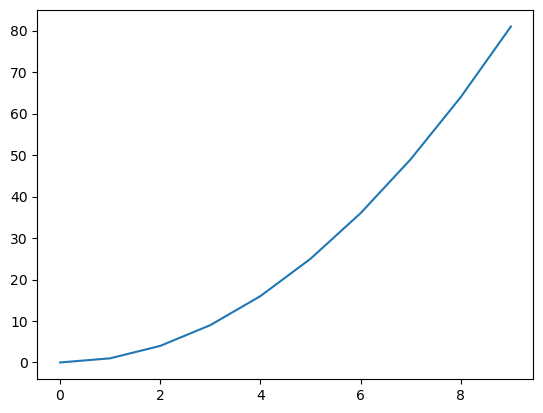

In [93]:
x_list = [ i for i in range(10) ]
y_list = [ x**2 for x in x_list ]

plt.plot(x_list, y_list)

**Exercise:** Use the function `y` defined previously to plot the height over time of an object dropped (from rest) from a height of $1,000$ meters (on Earth) for the range $0 \leq t \leq 16$.